In [139]:
import h5py

# Open the file in read-only mode
with h5py.File('/home/shared/data/toy_squares/train/data.hdf5', 'r') as f:
    # Print the top-level keys
    print(list(f['data']['demo_0']['obs']['image'].shape))

[84, 128, 128, 3]


In [ ]:
import json
import os
import random
import sys
from copy import deepcopy
from pathlib import Path
import mlflow
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import spearmanr
from torch.utils.data import DataLoader, Dataset
from torch._higher_order_ops import scan
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / "guidance").exists() and (repo_root.parent / "guidance").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import corallab_stl.torch as stl
from corallab_stl.automata import get_spot_formula_and_aps

from guidance.label_world_model import add_labels
from guidance.utils.data import (
    DynamicsTransitionDataset,
    build_trajectory_dataset,
    flatten_trajectory_dataset,
    collect_trajectories,
    compute_normalization_stats,
    get_demo_keys,
    split_trajectories,
)
from guidance.world_model_utils import (
    DynamicsMLP,
    build_state_from_obs_dict,
    deconstruct_state,
    load_model_for_eval,
    plot_rzz_world_model_branches,
    predict_next_state_from_raw,
    quat_to_6d,
    reconstruct_rotation_matrix_from_6d,
    rollout_policy_for_rzz_analysis,
    rzz_from_state_29d,
    xyzw_to_wxyz_batch,
)


# Data Preparation

In [140]:
dataset_path = "/home/shared/data/toy_squares/train/data.hdf5"
demos = [(dataset_path, k) for k in get_demo_keys(dataset_path)]
trajectories = build_trajectory_dataset(
    demos,
    state_components=[
        lambda s: s["agent_pos"][:],
        lambda s: s["states"][:],  # blue, red, green, yellow
    ],
)

state_var = stl.Var(
    "state",
    dim=10,
    agent_pos=(0, 2),
    blue_pos=(2, 4),
    red_pos=(4, 6),
    green_pos=(6, 8),
    yellow_pos=(8, 10),
)

cube_radius = 0.2
at_blue = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[2:4]).norm(), 0.0)
at_red = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[4:6]).norm(), 0.0)
at_green = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[6:8]).norm(), 0.0)
at_yellow = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[8:10]).norm(), 0.0)

trajectories = add_labels(trajectories, [at_green, at_blue, at_red, at_yellow])

print(f"Loaded {len(trajectories)} trajectories")
print(trajectories[0]["labels"].shape, trajectories[0]["next_labels"].shape)


Trajectory Dataset Summary:
 - Num trajectories: 10000
 - Num transitions:  588916
 - State dim:        10
 - Action dim:       2
Loaded 10000 trajectories
torch.Size([84, 4]) torch.Size([84, 4])



Processed 10000 trajectories
Trajectories with no nonzero label vector: 612
Most common offsets from the end: [(0, 3335), (1, 3284), (2, 1374), (3, 500), (4, 114), (5, 50), (17, 22), (32, 21), (22, 21), (8, 21)]


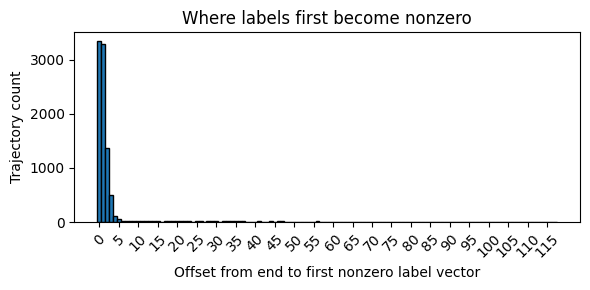

In [142]:
from collections import Counter

label_first_nonzero_indices = []
label_lengths = []
trajectories_with_no_nonzero = []

for traj_idx, traj in enumerate(trajectories):
    labels = np.asarray(traj["labels"])
    label_lengths.append(len(labels))

    if labels.ndim == 1:
        nonzero_mask = labels != 0
    else:
        nonzero_mask = np.any(labels != 0, axis=-1)

    nonzero_indices = np.flatnonzero(nonzero_mask)
    if len(nonzero_indices) == 0:
        trajectories_with_no_nonzero.append(traj_idx)
        label_first_nonzero_indices.append(None)
        # print(f"trajectory {traj_idx}: no nonzero label vector found")
    else:
        first_nonzero_idx = int(nonzero_indices[0])
        label_first_nonzero_indices.append(first_nonzero_idx)
        offset_from_end = len(labels) - first_nonzero_idx - 1
        # print(
        #     f"trajectory {traj_idx}: first nonzero label vector at index {first_nonzero_idx} "
        #     f"(offset from end = {offset_from_end})"
        # )

valid_offsets = [
    len(traj["labels"]) - idx - 1
    for traj, idx in zip(trajectories, label_first_nonzero_indices)
    if idx is not None
]

print()
print(f"Processed {len(trajectories)} trajectories")
print(f"Trajectories with no nonzero label vector: {len(trajectories_with_no_nonzero)}")

if valid_offsets:
    offset_counts = Counter(valid_offsets)
    print("Most common offsets from the end:", offset_counts.most_common(10))

    plt.figure(figsize=(6, 3))
    max_offset = max(valid_offsets)
    bins = np.arange(-0.5, max_offset + 1.5, 1.0)
    plt.hist(valid_offsets, bins=bins, edgecolor="black")
    plt.xlabel("Offset from end to first nonzero label vector")
    plt.ylabel("Trajectory count")
    plt.title("Where labels first become nonzero")
    tick_step = max(1, max_offset // 20)
    plt.xticks(range(0, max_offset + 1, tick_step), rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No trajectories with nonzero label vectors were found, so no histogram was plotted.")


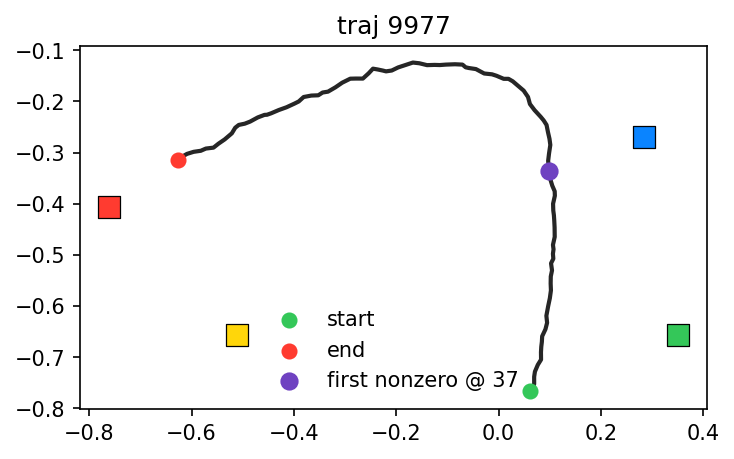

In [143]:
traj_idx = 9977
traj = trajectories[traj_idx]
states = np.asarray(traj["states"])
labels = np.asarray(traj["labels"])
agent = states[:, :2]
cubes = states[0, 2:10].reshape(4, 2)
first_nz = np.flatnonzero(np.any(labels != 0, axis=-1))

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.plot(agent[:, 0], agent[:, 1], c="black", lw=2, alpha=0.85)
ax.scatter(agent[0, 0], agent[0, 1], c="#34c759", s=45, label="start", zorder=3)
ax.scatter(agent[-1, 0], agent[-1, 1], c="#ff3b30", s=45, label="end", zorder=3)
ax.scatter(cubes[:, 0], cubes[:, 1], s=110, marker="s", c=["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"], edgecolors="k", linewidths=0.6, zorder=2)
if len(first_nz):
    i = int(first_nz[0])
    ax.scatter(agent[i, 0], agent[i, 1], c="#6f42c1", s=60, label=f"first nonzero @ {i}", zorder=4)
else:
    ax.text(0.02, 0.98, "labels never become nonzero", transform=ax.transAxes, va="top")

ax.set_title(f"traj {traj_idx}")
ax.set_aspect("equal")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
split_seed = 42
import importlib
import guidance.utils.data as data_utils
data_utils = importlib.reload(data_utils)
action_horizon = 8
flatten_fn = lambda trajs, keys: flatten_trajabout youectory_dataset(trajs, keys=keys, action_horizon=action_horizon)
train_trajectories, val_trajectories = split_trajectories(
    trajectories,
    val_ratio=0.2,
    seed=split_seed,
)

keys = ["states", "actions", "labels", "next_labels"]

# IMPORTANT: normalize using train split only
stats = compute_normalization_stats(train_trajectories, keys=keys, flatten_fn=flatten_fn)

train_dataset = DynamicsTransitionDataset(train_trajectories, stats, keys=keys, normalization_blacklist=["labels", "next_labels"], flatten_fn=flatten_fn)
val_dataset = DynamicsTransitionDataset(val_trajectories, stats, keys=keys, normalization_blacklist=["labels", "next_labels"], flatten_fn=flatten_fn)

print("train sample shapes:", {k: v.shape for k, v in train_dataset[0].items()})
print("val sample shapes:", {k: v.shape for k, v in val_dataset[0].items()})

Split Summary:
 - Total trajectories: 10000
 - Train trajectories: 8000
 - Val trajectories:   2000
train sample shapes: {'states': torch.Size([10]), 'actions': torch.Size([16]), 'labels': torch.Size([4]), 'next_labels': torch.Size([4])}
val sample shapes: {'states': torch.Size([10]), 'actions': torch.Size([16]), 'labels': torch.Size([4]), 'next_labels': torch.Size([4])}


Train next_label distribution
0 0 0 0: 3702
1 0 0 0: 97456
0 1 0 0: 100915
0 0 1 0: 101085
0 0 0 1: 103865


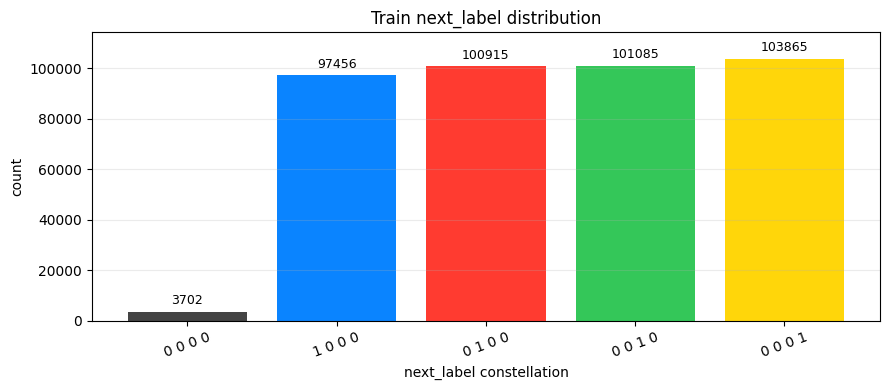

Validation next_label distribution
0 0 0 0: 939
1 0 0 0: 26045
0 1 0 0: 24103
0 0 1 0: 24580
0 0 0 1: 25585


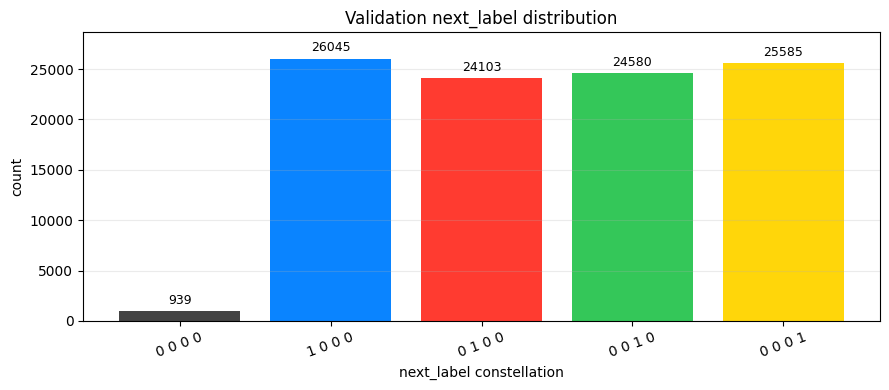

In [145]:
# Output Label Distribution

from collections import Counter

def label_tuple_counts(dataset, key="next_labels"):
    counts = Counter()
    for idx in range(len(dataset)):
        label = dataset[idx][key]
        if hasattr(label, "detach"):
            label = label.detach().cpu().numpy()
        else:
            label = np.asarray(label)
        counts[tuple(int(x) for x in label.tolist())] += 1
    return counts

def print_and_plot_label_counts(counts, title):
    all_labels = [(0, 0, 0, 0), (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0), (0, 0, 0, 1)]
    labels = [" ".join(map(str, label)) for label in all_labels]
    values = [counts.get(label, 0) for label in all_labels]

    print(title)
    for label, value in zip(labels, values):
        print(f"{label}: {value}")

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(labels, values, color=["#444444", "#0a84ff", "#ff3b30", "#34c759", "#ffd60a"])
    ax.set_title(title)
    ax.set_xlabel("next_label constellation")
    ax.set_ylabel("count")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, max(values) * 1.1 if values else 1)
    ax.bar_label(bars, padding=3, fontsize=9)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


train_next_label_counts = label_tuple_counts(train_dataset, key="next_labels")
val_next_label_counts = label_tuple_counts(val_dataset, key="next_labels")

print_and_plot_label_counts(train_next_label_counts, "Train next_label distribution")
print_and_plot_label_counts(val_next_label_counts, "Validation next_label distribution")

# Automaton World Model Training 

In [146]:
class AutomatonMLP(nn.Module):
    def __init__(self, state_dim=10, label_dim=4, action_chunk_dim=16, state_hidden=16, label_hidden=4, action_hidden=16, hidden_dim=32):
        super().__init__()
        self.state_enc = nn.Sequential(nn.Linear(state_dim, state_hidden), nn.SiLU(), nn.Linear(state_hidden, state_hidden), nn.SiLU())
        self.label_enc = nn.Sequential(nn.Linear(label_dim, label_hidden), nn.SiLU(), nn.Linear(label_hidden, label_hidden), nn.SiLU())
        self.action_enc = nn.Sequential(nn.Linear(action_chunk_dim, action_hidden), nn.SiLU(), nn.Linear(action_hidden, action_hidden), nn.SiLU())
        self.head = nn.Sequential(nn.Linear(state_hidden + label_hidden + action_hidden, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, 4))

    def forward(self, s_t, a_chunk, label_t):
        z = torch.cat([self.state_enc(s_t), self.action_enc(a_chunk), self.label_enc(label_t)], dim=-1)
        return self.head(z)

In [147]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DataLoader setup for deterministic shuffling
batch_size = 256
loader_generator = torch.Generator()
loader_generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

In [148]:
from datetime import datetime

device = "cuda" if torch.cuda.is_available() else "cpu"
label_names = ["at_green", "at_blue", "at_red", "at_yellow"]

# Instantiate model, optimizer, and loss function
model = AutomatonMLP(state_dim=10, label_dim=4, action_chunk_dim=16)
model = model.to(device)
print(f"Model created. Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using Device: {device}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

# Training configuration
num_epochs = 200
best_val_loss = float("inf")
patience = 50
epochs_since_improvement = 0

# Reproducible run directory and artifact paths
run_root = repo_root / "outputs" / "automaton_world_model"
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_dir = run_root / f"training-run_{run_timestamp}"
run_suffix = 1
while run_dir.exists():
    run_dir = run_root / f"training-run_{run_timestamp}_{run_suffix}"
    run_suffix += 1
run_dir.mkdir(parents=True, exist_ok=False)

checkpoint_path = run_dir / "best_model.pt"
final_checkpoint_path = run_dir / "final_model.pt"
config_path = run_dir / "train_config.json"
norm_stats_path = run_dir / "normalization_stats.npz"
provenance_path = run_dir / "data_provenance.json"
stats_summary_path = run_dir / "training_stats.json"
loss_plot_path = run_dir / "training_loss_curves.png"

# Persist normalization stats needed for loading and inference
np.savez_compressed(norm_stats_path, **stats)

# Persist dataset provenance for reproducibility
selected_demo_refs = [{"path": p, "demo_id": d} for p, d in demos]
train_demo_refs = [{"path": tr["path"], "demo_id": tr["demo_id"]} for tr in train_trajectories]
val_demo_refs = [{"path": tr["path"], "demo_id": tr["demo_id"]} for tr in val_trajectories]

provenance = {
    "seed": seed,
    "split_seed": split_seed,
    "dataset_path": dataset_path,
    "action_horizon": action_horizon,
    "label_names": label_names,
    "keys": keys,
    "normalization_blacklist": ["labels", "next_labels"],
    "selected_demos": selected_demo_refs,
    "train_demos": train_demo_refs,
    "val_demos": val_demo_refs,
}

with open(provenance_path, "w") as f:
    json.dump(provenance, f, indent=2)

training_config = {
    "run_dir": str(run_dir),
    "seed": seed,
    "split_seed": split_seed,
    "dataset_path": dataset_path,
    "action_horizon": action_horizon,
    "label_names": label_names,
    "keys": keys,
    "state_dim": 10,
    "label_dim": 4,
    "action_chunk_dim": 16,
    "state_hidden": 128,
    "label_hidden": 32,
    "action_hidden": 128,
    "hidden_dim": 256,
    "activation": "SiLU",
    "output_dim": 4,
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "optimizer": "Adam",
    "loss_fn": "BCEWithLogitsLoss",
    "patience": patience,
    "num_train_samples": len(train_dataset),
    "num_val_samples": len(val_dataset),
    "checkpoint_path": str(checkpoint_path),
    "final_checkpoint_path": str(final_checkpoint_path),
    "normalization_stats_path": str(norm_stats_path),
    "data_provenance_path": str(provenance_path),
    "training_stats_path": str(stats_summary_path),
    "loss_plot_path": str(loss_plot_path),
}

with open(config_path, "w") as f:
    json.dump(training_config, f, indent=2)

print(f"Run directory: {run_dir}")
print(f"Training config saved to {config_path}")
print(f"Normalization stats saved to {norm_stats_path}")
print(f"Data provenance saved to {provenance_path}")

Model created. Total parameters: 3,404
Using Device: cuda
Run directory: /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48
Training config saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/train_config.json
Normalization stats saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/normalization_stats.npz
Data provenance saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/data_provenance.json


In [149]:
# training loop

train_losses = []
val_losses = []
best_epoch = -1
last_epoch_trained = -1

for epoch in range(num_epochs):
    last_epoch_trained = epoch

    # ===== train epoch =====
    model.train()
    train_loss_sum = 0.0
    train_batches = 0

    for batch in train_loader:
        s_t = batch["states"].to(device)
        a_chunk = batch["actions"].to(device)
        label_t = batch["labels"].to(device)
        next_label_t = batch["next_labels"].to(device)

        optimizer.zero_grad()
        next_label_logits = model(s_t, a_chunk, label_t)
        loss = loss_fn(next_label_logits, next_label_t)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1

    train_loss = train_loss_sum / max(1, train_batches)
    train_losses.append(train_loss)

    # ===== val epoch =====
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            s_t = batch["states"].to(device)
            a_chunk = batch["actions"].to(device)
            label_t = batch["labels"].to(device)
            next_label_t = batch["next_labels"].to(device)

            next_label_logits = model(s_t, a_chunk, label_t)
            loss = loss_fn(next_label_logits, next_label_t)

            val_loss_sum += loss.item()
            val_batches += 1

    val_loss = val_loss_sum / max(1, val_batches)
    val_losses.append(val_loss)

    # ===== checkpoint best model =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_since_improvement = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "model_config": {
                    "state_dim": 10,
                    "label_dim": 4,
                    "action_chunk_dim": 16,
                    "state_hidden": 128,
                    "label_hidden": 32,
                    "action_hidden": 128,
                    "hidden_dim": 256,
                    "activation": "silu",
                    "output_dim": 4,
                },
                "training_config": training_config,
                "normalization_stats": stats,
            },
            checkpoint_path,
        )
        print(f"epoch {epoch + 1:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f} | best")
    else:
        epochs_since_improvement += 1
        print(f"epoch {epoch + 1:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    if epochs_since_improvement >= patience:
        print(f"\nearly stopping at epoch {epoch + 1}. no improvement for {patience} epochs.")
        break

# save final checkpoint as well for exact end-of-training recovery
torch.save(
    {
        "epoch": last_epoch_trained,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_losses[-1] if train_losses else None,
        "val_loss": val_losses[-1] if val_losses else None,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "model_config": {
            "state_dim": 10,
            "label_dim": 4,
            "action_chunk_dim": 16,
            "state_hidden": 128,
            "label_hidden": 32,
            "action_hidden": 128,
            "hidden_dim": 256,
            "activation": "silu",
            "output_dim": 4,
        },
        "training_config": training_config,
        "normalization_stats": stats,
    },
    final_checkpoint_path,
 )

training_stats = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
    "best_epoch": best_epoch,
    "num_epochs_trained": len(train_losses),
    "run_dir": str(run_dir),
    "checkpoint_path": str(checkpoint_path),
    "final_checkpoint_path": str(final_checkpoint_path),
    "normalization_stats_path": str(norm_stats_path),
    "data_provenance_path": str(provenance_path),
}

with open(stats_summary_path, "w") as f:
    json.dump(training_stats, f, indent=2)


epoch   1 | train loss: 0.540732 | val loss: 0.462957 | best
epoch   2 | train loss: 0.420985 | val loss: 0.406868 | best
epoch   3 | train loss: 0.385464 | val loss: 0.378673 | best
epoch   4 | train loss: 0.345176 | val loss: 0.343595 | best
epoch   5 | train loss: 0.307940 | val loss: 0.315741 | best
epoch   6 | train loss: 0.282439 | val loss: 0.296905 | best
epoch   7 | train loss: 0.267227 | val loss: 0.294978 | best
epoch   8 | train loss: 0.257037 | val loss: 0.288204 | best
epoch   9 | train loss: 0.250218 | val loss: 0.285819 | best
epoch  10 | train loss: 0.244985 | val loss: 0.280239 | best
epoch  11 | train loss: 0.240808 | val loss: 0.285027
epoch  12 | train loss: 0.237178 | val loss: 0.283887
epoch  13 | train loss: 0.234296 | val loss: 0.283653
epoch  14 | train loss: 0.231851 | val loss: 0.290392
epoch  15 | train loss: 0.229559 | val loss: 0.282711
epoch  16 | train loss: 0.227631 | val loss: 0.282166
epoch  17 | train loss: 0.225830 | val loss: 0.287319
epoch  18 | 

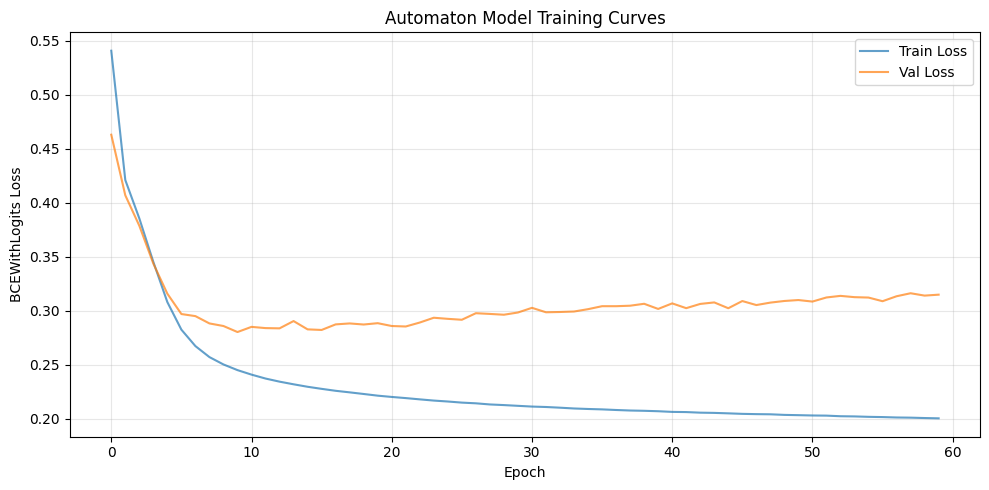


Training complete. Best val loss: 0.280239 (epoch 10)
Best checkpoint saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/best_model.pt
Final checkpoint saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/final_model.pt
Training stats saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/training_stats.json
Loss curves saved to /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48/training_loss_curves.png
All run artifacts are in: /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_23-00-48


In [150]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train Loss", alpha=0.7)
ax.plot(val_losses, label="Val Loss", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogits Loss")
ax.set_title("Automaton Model Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=100)
plt.show()

print(f"\nTraining complete. Best val loss: {best_val_loss:.6f} (epoch {best_epoch + 1})")
print(f"Best checkpoint saved to {checkpoint_path}")
print(f"Final checkpoint saved to {final_checkpoint_path}")
print(f"Training stats saved to {stats_summary_path}")
print(f"Loss curves saved to {loss_plot_path}")
print(f"All run artifacts are in: {run_dir}")

# Model Testing 

In [173]:
# Load trained automaton model and simple baselines for eval

toy_squares_state_components = [
    lambda s: s["agent_pos"][:],
    lambda s: s["states"][:],  # blue, red, green, yellow
]

class BaselineLogitPredictor(nn.Module):
    def __init__(self, logits):
        super().__init__()
        self.register_buffer("logits", torch.as_tensor(logits, dtype=torch.float32))

    def forward(self, s_t, a_chunk, label_t):
        batch_size = s_t.shape[0]
        return self.logits.unsqueeze(0).expand(batch_size, -1)


def _label_mean_from_trajectories(trajectories, key="next_labels"):
    label_arrays = [np.asarray(tr[key], dtype=np.float32) for tr in trajectories if key in tr]
    if not label_arrays:
        raise ValueError(f"Could not compute label mean: no '{key}' arrays were found.")
    return np.mean(np.concatenate(label_arrays, axis=0), axis=0)


def load_automaton_model_for_eval(
    model_or_run_path,
    device,
    predictor_kind="learned",
    state_dim=10,
    label_dim=4,
    action_chunk_dim=16,
    state_hidden=128,
    label_hidden=32,
    action_hidden=128,
    hidden_dim=256,
    load_val_trajectories=False,
    build_trajectory_dataset_fn=None,
    fallback_val_trajectories=None,
    state_components=None,
):
    if os.path.isdir(model_or_run_path):
        run_dir_local = Path(model_or_run_path)
        ckpt_path_local = run_dir_local / "best_model.pt"
    else:
        ckpt_path_local = Path(model_or_run_path)
        run_dir_local = ckpt_path_local.parent

    if not ckpt_path_local.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path_local}")

    ckpt_local = torch.load(ckpt_path_local, map_location=device, weights_only=False)
    state_dict_local = ckpt_local["model_state_dict"]

    eval_stats_local = ckpt_local.get("normalization_stats")
    if eval_stats_local is None:
        norm_path_local = run_dir_local / "normalization_stats.npz"
        if not norm_path_local.exists():
            raise FileNotFoundError(
                f"No normalization stats found in checkpoint and no file at {norm_path_local}."
            )
        z = np.load(norm_path_local)
        eval_stats_local = {k: z[k] for k in z.files}

    for k in ["states_mean", "states_std", "actions_mean", "actions_std", "labels_mean", "labels_std", "next_labels_mean", "next_labels_std"]:
        if k in eval_stats_local:
            eval_stats_local[k] = np.asarray(eval_stats_local[k], dtype=np.float32)

    state_dim_local = int(state_dict_local["state_enc.0.weight"].shape[1])
    state_hidden_local = int(state_dict_local["state_enc.0.weight"].shape[0])
    label_dim_local = int(state_dict_local["label_enc.0.weight"].shape[1])
    label_hidden_local = int(state_dict_local["label_enc.0.weight"].shape[0])
    action_chunk_dim_local = int(state_dict_local["action_enc.0.weight"].shape[1])
    action_hidden_local = int(state_dict_local["action_enc.0.weight"].shape[0])
    hidden_dim_local = int(state_dict_local["head.0.weight"].shape[0])

    if predictor_kind == "learned":
        predictor_local = AutomatonMLP(
            state_dim=state_dim_local,
            label_dim=label_dim_local,
            action_chunk_dim=action_chunk_dim_local,
            state_hidden=state_hidden_local,
            label_hidden=label_hidden_local,
            action_hidden=action_hidden_local,
            hidden_dim=hidden_dim_local,
        ).to(device)
        predictor_local.load_state_dict(state_dict_local)
        predictor_local.eval()
    elif predictor_kind == "baseline_zero":
        predictor_local = BaselineLogitPredictor(np.zeros(label_dim_local, dtype=np.float32)).to(device)
        predictor_local.eval()
    elif predictor_kind == "baseline_mean":
        label_mean = ckpt_local.get("label_mean")
        if label_mean is None:
            if fallback_val_trajectories is not None:
                label_mean = _label_mean_from_trajectories(fallback_val_trajectories, key="next_labels")
            elif "train_trajectories" in globals():
                label_mean = _label_mean_from_trajectories(train_trajectories, key="next_labels")
            else:
                raise RuntimeError(
                    "No label_mean found in the checkpoint and no trajectories were provided to compute it."
                )
        label_mean = np.asarray(label_mean, dtype=np.float32)
        label_mean = np.clip(label_mean, 1e-4, 1.0 - 1e-4)
        label_logits = np.log(label_mean / (1.0 - label_mean))
        predictor_local = BaselineLogitPredictor(label_logits.astype(np.float32)).to(device)
        predictor_local.eval()
    else:
        raise ValueError(
            f"Unknown predictor_kind='{predictor_kind}'. Use one of: learned, baseline_zero, baseline_mean"
        )

    val_trajectories_local = None
    if load_val_trajectories:
        provenance_path_local = run_dir_local / "data_provenance.json"
        if provenance_path_local.exists():
            with open(provenance_path_local, "r", encoding="utf-8") as f:
                prov_local = json.load(f)
            val_demo_refs_local = [(x["path"], x["demo_id"]) for x in prov_local["val_demos"]]
            if build_trajectory_dataset_fn is None:
                raise RuntimeError(
                    "build_trajectory_dataset_fn is required when load_val_trajectories=True and provenance exists."
                )
            val_trajectories_local = build_trajectory_dataset_fn(
                val_demo_refs_local,
                state_components=state_components if state_components is not None else [],
            )
            if val_trajectories_local and "labels" not in val_trajectories_local[0]:
                if not all(name in globals() for name in ["at_green", "at_blue", "at_red", "at_yellow"]):
                    raise RuntimeError(
                        "Loaded trajectories are missing labels and the label predicates are not available in globals()."
                    )
                val_trajectories_local = add_labels(
                    val_trajectories_local,
                    [at_green, at_blue, at_red, at_yellow],
                )
        elif fallback_val_trajectories is not None:
            val_trajectories_local = fallback_val_trajectories
        else:
            raise RuntimeError(
                "No data_provenance.json found and no fallback_val_trajectories were provided."
            )

    eval_meta_local = {
        "run_dir": str(run_dir_local),
        "ckpt_path": str(ckpt_path_local),
        "provenance_path": str(run_dir_local / "data_provenance.json"),
        "norm_path": str(run_dir_local / "normalization_stats.npz"),
        "predictor_kind": predictor_kind,
    }
    return predictor_local, eval_stats_local, val_trajectories_local, eval_meta_local


In [174]:
loaded_model_path = '../outputs/automaton_world_model/training-run_2026-04-28_17-52-27/'
predictor_learned, eval_stats, loaded_val_trajectories, eval_meta = load_automaton_model_for_eval(
    model_or_run_path=loaded_model_path,
    predictor_kind="learned",
    device=device,
    load_val_trajectories=True,
    build_trajectory_dataset_fn=build_trajectory_dataset,
    fallback_val_trajectories=val_trajectories if "val_trajectories" in globals() else None,
    state_components=toy_squares_state_components,
)

predictor_zero, _, _, _ = load_automaton_model_for_eval(
    model_or_run_path=loaded_model_path,
    predictor_kind="baseline_zero",
    device=device,
)

predictor_mean, _, _, _ = load_automaton_model_for_eval(
    model_or_run_path=loaded_model_path,
    predictor_kind="baseline_mean",
    device=device,
    fallback_val_trajectories=train_trajectories if "train_trajectories" in globals() else None,
)

stats = eval_stats

print(f"Loaded learned model from: {eval_meta['ckpt_path']}")
print(f"Loaded run directory: {eval_meta['run_dir']}")
print(f"Validation trajectories loaded: {len(loaded_val_trajectories) if loaded_val_trajectories is not None else 0}")
print("Baseline predictors ready: zero and mean")
print(f"Mean predictor logits: {predictor_mean.logits.detach().cpu().numpy()}")

Trajectory Dataset Summary:
 - Num trajectories: 2000
 - Num transitions:  117510
 - State dim:        10
 - Action dim:       2
Loaded learned model from: ../outputs/automaton_world_model/training-run_2026-04-28_17-52-27/best_model.pt
Loaded run directory: ../outputs/automaton_world_model/training-run_2026-04-28_17-52-27
Validation trajectories loaded: 2000
Baseline predictors ready: zero and mean
Mean predictor logits: [-1.1484212 -1.1053723 -1.1016637 -1.0740594]


In [185]:
# First 8 actions from the first validation trajectory as one action chunk

def _as_tensor_2d(x):
    return torch.as_tensor(np.asarray(x), dtype=torch.float32, device=device).unsqueeze(0)


def _print_model_output(name, predictor, state_0, action_chunk, label_0):
    print(f"\n{name}")
    print("-" * 80)
    with torch.no_grad():
        logits = predictor(state_0, action_chunk, label_0)[0].detach().cpu().numpy()
        probs = torch.sigmoid(torch.from_numpy(logits)).numpy()
    print(f"logits={np.array2string(logits, precision=4)}")
    print(f"probs ={np.array2string(probs, precision=4)}")


if loaded_val_trajectories is None or len(loaded_val_trajectories) == 0:
    raise ValueError("No validation trajectories were loaded.")

val_demo = loaded_val_trajectories[10]
num_actions = min(8, len(val_demo["actions"]))
state_0 = _as_tensor_2d(val_demo["states"][0])
action_chunk = _as_tensor_2d(val_demo["actions"][:num_actions].reshape(-1))
label_0 = _as_tensor_2d(val_demo["labels"][0]) if "labels" in val_demo else torch.zeros((1, 4), dtype=torch.float32, device=device)

print(f"Validation demo: {val_demo['demo_id']}")
print(f"Trajectory path: {val_demo['path']}")
print(f"Using first {num_actions} actions as a single chunk")

_print_model_output("Learned model", predictor_learned, state_0, action_chunk, label_0)
_print_model_output("Zero predictor", predictor_zero, state_0, action_chunk, label_0)
_print_model_output("Mean predictor", predictor_mean, state_0, action_chunk, label_0)




Validation demo: demo_9098
Trajectory path: /home/shared/data/toy_squares/train/data.hdf5
Using first 8 actions as a single chunk

Learned model
--------------------------------------------------------------------------------
logits=[-0.0536 -1.9847 -1.1502 -0.419 ]
probs =[0.4866 0.1208 0.2405 0.3967]

Zero predictor
--------------------------------------------------------------------------------
logits=[0. 0. 0. 0.]
probs =[0.5 0.5 0.5 0.5]

Mean predictor
--------------------------------------------------------------------------------
logits=[-1.1484 -1.1054 -1.1017 -1.0741]
probs =[0.2408 0.2487 0.2494 0.2546]


In [196]:
if loaded_val_trajectories is None or len(loaded_val_trajectories) == 0:
    raise ValueError("No validation trajectories were loaded.")

val_demo = loaded_val_trajectories[20]
states = np.asarray(val_demo["states"])
actions = np.asarray(val_demo["actions"])
true_next_labels = np.asarray(val_demo.get("next_labels", val_demo.get("labels")))
current_labels = np.asarray(val_demo.get("labels", true_next_labels))
num_steps = len(actions) - action_horizon

print(f"Validation demo: {val_demo['demo_id']}")
print(f"Trajectory path: {val_demo['path']}")
print(f"Trajectory steps: {num_steps}")

for t in range(num_steps):
    s_t = _as_tensor_2d(states[t])
    a_t = _as_tensor_2d(actions[t : t + action_horizon].reshape(-1))
    label_t = _as_tensor_2d(current_labels[t])
    with torch.no_grad():
        logits = predictor_learned(s_t, a_t, label_t)[0].detach().cpu().numpy()
        pred_labels = torch.sigmoid(torch.from_numpy(logits)).numpy()
    pred_str = np.array2string(
        pred_labels,
        formatter={"float_kind": lambda x: f"{x:.3f}"},
        separator=", ",
    )
    true_str = np.array2string(
        true_next_labels[t],
        formatter={"float_kind": lambda x: f"{x:.3f}"},
        separator=", ",
    )
    print(f"t={t:03d} pred_labels={pred_str} true_next_labels={true_str}")

Validation demo: demo_7081
Trajectory path: /home/shared/data/toy_squares/train/data.hdf5
Trajectory steps: 59
t=000 pred_labels=[0.670, 0.195, 0.413, 0.080] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=001 pred_labels=[0.665, 0.192, 0.421, 0.081] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=002 pred_labels=[0.633, 0.224, 0.414, 0.091] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=003 pred_labels=[0.646, 0.206, 0.423, 0.086] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=004 pred_labels=[0.691, 0.193, 0.401, 0.075] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=005 pred_labels=[0.715, 0.175, 0.394, 0.069] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=006 pred_labels=[0.712, 0.177, 0.398, 0.070] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=007 pred_labels=[0.732, 0.175, 0.377, 0.067] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=008 pred_labels=[0.688, 0.188, 0.408, 0.075] true_next_labels=[1.000, 0.000, 0.000, 0.000]
t=009 pred_labels=[0.686, 0.166, 0.432, 0.071] true_